In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Set the constants
T0 = 1.0                      # planar channel temperature
Uw = 0.1                      # wall velocity
Np = 50000                    # particles 
nc = 50                       # number of cells
L = 1.0                       # distance between plates 
Tw = 1.0                      # wall temperature
m = 1.0                       # mass of argon 
k = 1.0                       # Boltzmann constant
tau = 0.05                    # relaxation time 
t = 0                         # initial time
t_end = 5                     # final time
dt = 0.001                    # timestep
Nsteps = int(t_end // dt) + 1 # number of steps
Nc = 10                       # number of cells
dx = L / Nc                   # space grid length

In [8]:
def compute_cell_moments(M, cell_index, Nc, m, k):
    """Compute mean velocity and temperature for all cells."""
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)

def compute_cell_moments(M, cell_index, Nc, m, k):
    """Compute mean velocity and temperature for all cells."""
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)
    for c in range(Nc):
        mask = cell_index == c
        if mask.any():
            M_cell = M[mask]
            U[c] = M_cell.mean(axis=0)
            T[c] = (m / (3*k)) * ((M_cell - U[c])**2).mean()
    return U, T

In [9]:
# This deals with hitting the wall
def apply_wall_bc(X, V1, V2, V3, step, dt, L, Tw, Uw, m, k):
    left_mask = X[step, :] < -L/2 # for those particles hitting the left bar
    if left_mask.any():
        
        X_old = X[step-1, left_mask]
        V1_old = V1[step-1, left_mask]
        
        t_hit = (-L/2 - X_old) / V1_old  # v1_old < 0
        dt_rest = dt - t_hit
        
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        
        V1_new = np.sqrt(-2*k*Tw/m * np.log(r1_left))
        V2_new = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        V3_new = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        
        X[step, left_mask] = -L/2 + V1_new * dt_rest
        V1[step, left_mask] = V1_new
        V2[step, left_mask] = V2_new
        V3[step, left_mask] = V3_new
    
    right_mask = X[step, :] > L/2
    if right_mask.any():

        X_old = X[step-1, right_mask]
        V1_old = V1[step-1, right_mask]
        
        t_hit = (L/2 - X_old) / V1_old  # v1_old > 0
        dt_rest = dt - t_hit
        
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        
        V1_new = -np.sqrt(-2*k*Tw/m * np.log(r1_right))
        V2_new = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        V3_new = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        
        # Move for remaining time
        X[step, right_mask] = L/2 + V1_new * dt_rest
        V1[step, right_mask] = V1_new
        V2[step, right_mask] = V2_new
        V3[step, right_mask] = V3_new
    return left_mask, right_mask

In [10]:
# Implementation of Algorithm 1
X = np.zeros([Nsteps, Np])
X[0, :] =  np.random.uniform(low=-L/2, high=L/2, size=Np)


r1 = np.random.uniform(size=Np)
r2 = np.random.uniform(size=Np)
r3 = np.random.uniform(size=Np)
r4 = np.random.uniform(size=Np)

V1 = np.zeros([Nsteps, Np])
V2 = np.zeros([Nsteps, Np])
V3 = np.zeros([Nsteps, Np])


V1[0, :] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2)
V2[0, :] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4)
V3[0, :] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4)


U1 = np.zeros([Nsteps, Nc])
U2 = np.zeros([Nsteps, Nc])
U3 = np.zeros([Nsteps, Nc])
T = np.zeros([Nsteps, Nc])


# Set the initial U1, U2, U3, T
cell_index = np.floor((X[0, :] + L/2) / dx).astype(int)
cell_index = np.clip(cell_index, 0, Nc-1)  # make sure no particle is out of bounds
for c in range(Nc):
    mask_c = (cell_index==c)
    
    # Compute moments
    if mask_c.any():
        V1_cell = V1[0, mask_c]
        V2_cell = V2[0, mask_c]
        V3_cell = V3[0, mask_c]

        # Mean velocity
        U1[0, c] = V1_cell.mean()
        U2[0, c] = V2_cell.mean()
        U3[0, c] = V3_cell.mean()

        # Temperature
        T[0, c] = (m / (3 * k)) * (
            ((V1_cell - U1[0, c])**2 + 
             (V2_cell - U2[0, c])**2 + 
             (V3_cell - U3[0, c])**2).mean()
        )        

for step in range(1, Nsteps):
    
    # Evolve X^i
    X[step,] = X[step - 1,] + dt * V1[step - 1,]
    
    # Apply B.C.
    left_mask, right_mask = apply_wall_bc(X, V1, V2, V3, step, dt, L, Tw, Uw, m, k)

    # Sort particles
    cell_index = np.floor((X[step, :] + L/2) / dx).astype(int)
    cell_index = np.clip(cell_index, 0, Nc-1)  # make sure no particle is out of bounds

    for c in range(Nc):
        mask_c = (cell_index==c)

        mask_wall = left_mask | right_mask        # particles that just hit wall
        mask_c_update = mask_c & (~mask_wall)     # exclude wall-hitting particles, because they are already handled

        # Evolve V^i
        if mask_c_update.any():
            # Deterministic term
            V1[step, mask_c_update] = V1[step - 1, mask_c_update] - dt/tau * (V1[step - 1, mask_c_update] - U1[step - 1, c])
            V2[step, mask_c_update] = V2[step - 1, mask_c_update] - dt/tau * (V2[step - 1, mask_c_update] - U2[step - 1, c])
            V3[step, mask_c_update] = V3[step - 1, mask_c_update] - dt/tau * (V3[step - 1, mask_c_update] - U3[step - 1, c])
            # Stochastic term
            V1[step, mask_c_update] += np.sqrt(2*k*T[step - 1,c]/(m*tau)) * np.random.normal(0, np.sqrt(dt), size=mask_c_update.sum())
            V2[step, mask_c_update] += np.sqrt(2*k*T[step - 1,c]/(m*tau)) * np.random.normal(0, np.sqrt(dt), size=mask_c_update.sum())
            V3[step, mask_c_update] += np.sqrt(2*k*T[step - 1,c]/(m*tau)) * np.random.normal(0, np.sqrt(dt), size=mask_c_update.sum())

        # Compute moments
        if mask_c.any():
            V1_cell = V1[step, mask_c]
            V2_cell = V2[step, mask_c]
            V3_cell = V3[step, mask_c]
    
            # Mean velocity
            U1[step, c] = V1_cell.mean()
            U2[step, c] = V2_cell.mean()
            U3[step, c] = V3_cell.mean()
    
            # Temperature
            T[step, c] = (m / (3 * k)) * (
                ((V1_cell - U1[step, c])**2 + 
                 (V2_cell - U2[step, c])**2 + 
                 (V3_cell - U3[step, c])**2).mean()
            )        

# Now we got V1, V2, V3, U1, U2, U3

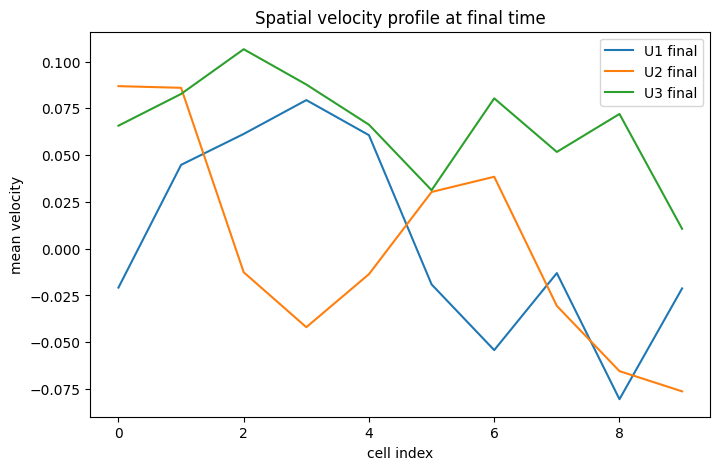

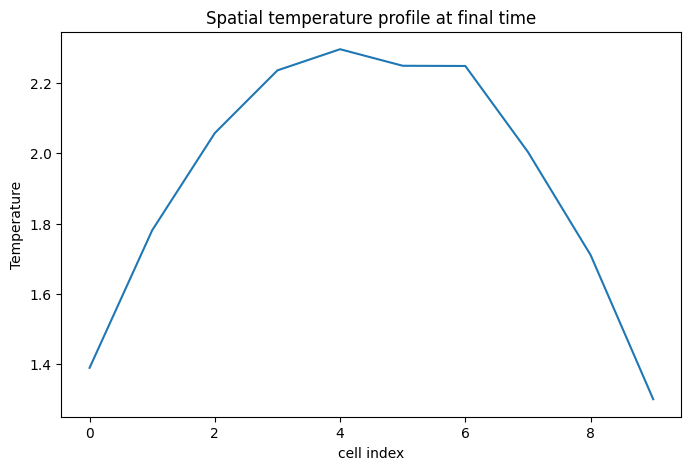

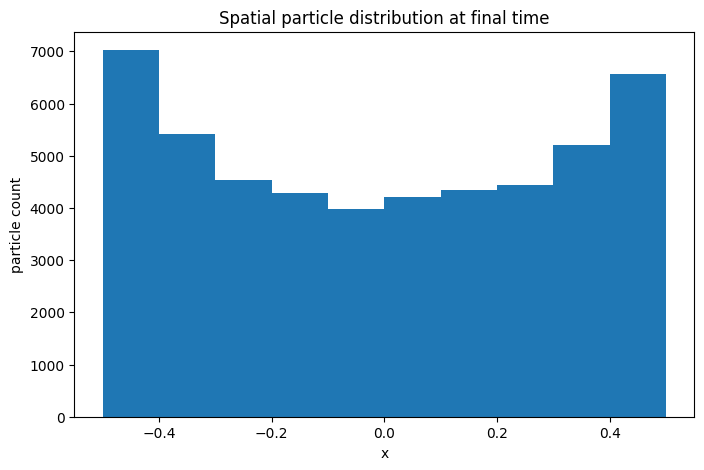

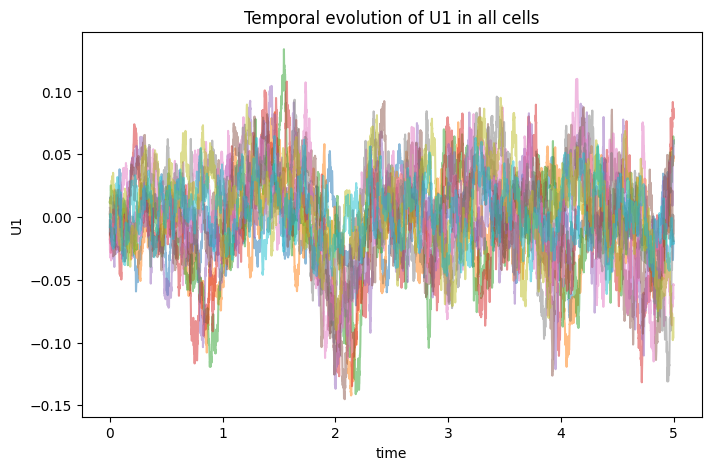

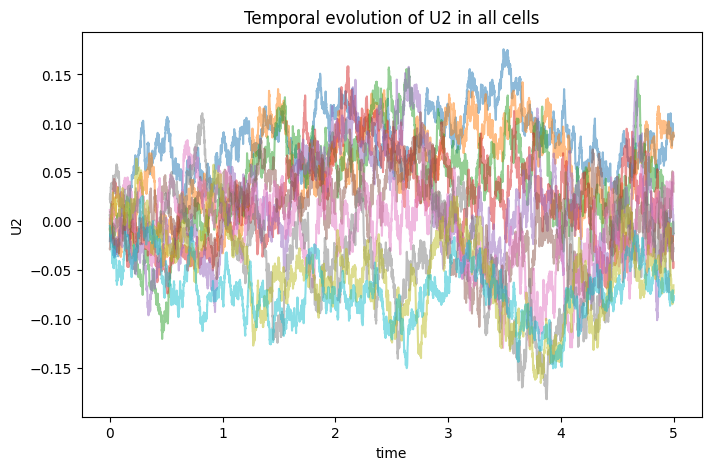

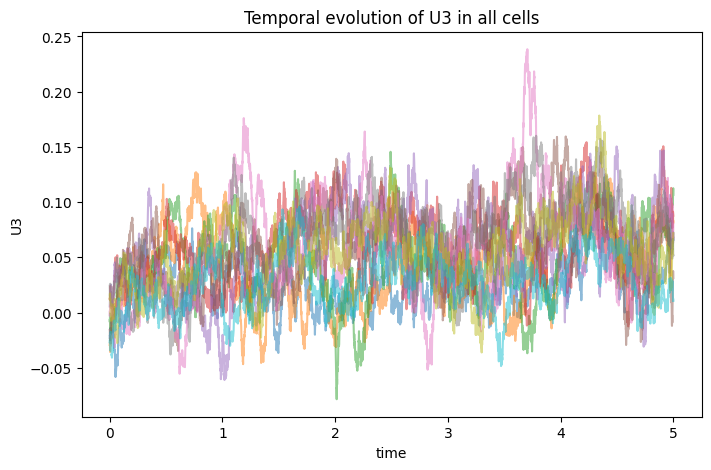

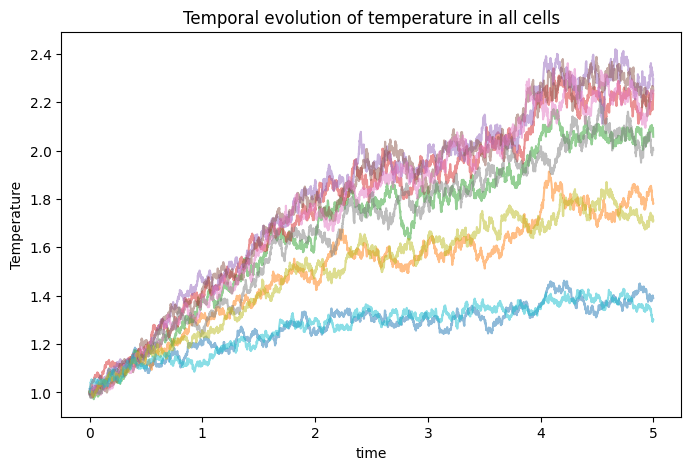

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U1[-1,:], label='U1 final')
plt.plot(range(Nc), U2[-1,:], label='U2 final')
plt.plot(range(Nc), U3[-1,:], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(X[-1,:], bins=Nc)
plt.xlabel('x')
plt.ylabel('particle count')
plt.title('Spatial particle distribution at final time')
plt.show()


plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U1[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U1')
plt.title('Temporal evolution of U1 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U2[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U2')
plt.title('Temporal evolution of U2 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U3[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U3')
plt.title('Temporal evolution of U3 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.title('Temporal evolution of temperature in all cells')
plt.show()